Our situation:

837 features

147 subjects

3 classes (HC, PD, DD)

This is called a high-dimensional, low-sample-size dataset.

What happened when we used all 837 features:

i. Many features are correlated or noisy

ii. The model overfits to random fluctuations

iii. Linear models struggle

iv. Tree models (RF, XGB) become unstable

v. Distance-based models (KNN) perform terribly

This is the classic curse of dimensionality.

With 837 features, the model needs hundreds or thousands of subjects- but we only have 147.

So reducing the number of features may reduce noise, increase signal, and prevent overfitting, giving higher test accuracy.

How many features should we keep?

From our previous work:

We already identified 164 statistically significant features using
Kruskal–Wallis → Mann–Whitney → FDR → Cliff’s delta.

Those 164 features are much cleaner and more meaningful than the full 837.

But even 164 may still be too many depending on the model.

Best features ranges for best accuracy:

i. Logistic Regression: 15-50

ii. SVM: 20-60

iii. KNN: <30

iv. Random Forest: 50-200

v. XGBoost: 30-200

The model can easily “memorize” the training data- but it cannot generalize.

When we reduce features:

i. We remove noise

ii. We remove redundant variables

iii. We force the model to learn true patterns

iv. We reduce overfitting

Thus, the model’s test performance improves.

Reducing our features is one of the most important ways to increase accuracy.

With 837 features and 147 subjects, our test accuracy will be poor due to overfitting.

Using our statistically selected 164 features and even further selecting the top 30–50 will significantly improve model performance.

# **About Dataset**

**Target**

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
'''
Target Variables
Diagnosis label: label
'''

'\nTarget Variables \nDiagnosis label: label\n'

In [ ]:
'''
This is what all our ML models (RF, SVM, etc.) are trying to predict.
label = diagnosis class:
0 = Healthy control (HC)
1 = Parkinson’s disease (PD)
2 = Other movement disorder (DD)
'''

'\nThis is what all our ML models (RF, SVM, etc.) are trying to predict.\nlabel = diagnosis class:\n0 = Healthy control (HC)\n1 = Parkinson’s disease (PD)\n2 = Other movement disorder (DD)\n'

**Input**

In [ ]:
'''
Input Variables (837)
Movement tasks: 11
left and right wrists: 2
Accelerometer and Gyroscope sensors: 2
X,Y,Z axis: 3
'''

'\nInput Variables (837)\nMovement tasks: 11\nleft and right wrists: 2\nAccelerometer and Gyroscope sensors: 2\nX,Y,Z axis: 3\n'

**Features**

In [ ]:
'''
Feature types:
SMA = signal magnitude area (combined X, Y, Z; no axis in name)
Mean = average value of the signal,
RMS = root mean square (overall intensity),
STD = standard deviation (variability),
ZCR = zero-crossing rate (how often the signal crosses zero → oscillations / tremor),
jerk_mean = mean of jerk (derivative of accel; how quickly acceleration changes),
jerk_rms = rms of jerk (intensity of acceleration changes)
'''

'\nFeature types: \nSMA = signal magnitude area (combined X, Y, Z; no axis in name)\nMean = average value of the signal, \nRMS = root mean square (overall intensity), \nSTD = standard deviation (variability), \nZCR = zero-crossing rate (how often the signal crosses zero → oscillations / tremor), \njerk_mean = mean of jerk (derivative of accel; how quickly acceleration changes), \njerk_rms = rms of jerk (intensity of acceleration changes)\n'

**Movement**

In [ ]:
'''
CrossArms = A motor task where the patient crosses both arms over the chest.
DrinkGlas = Simulated drinking motion: the patient picks up a cup or glass and brings it to their mouth.
Entrainment (stomping with arms lifted) = The patient stomps rhythmically (usually following a metronome) while lifting their arms.
HoldWeight = Patient holds a weight (light dumbbell or similar) steadily in front of the body.
LiftHold = Lifting an object or arm into a position and holding it still.
PointFinger = Patient extends the index finger and points to a target.
Relaxed = Patient remains still in a relaxed sitting or standing posture.
RelaxedTask = A relaxed posture with a mild imposed activity (e.g., light verbal task or minimal movement).
StretchHold = Patient stretches an arm or leg (e.g., fully extended) and holds the position.
TouchIndex = Touching the index fingers together or touching the index finger to a target.
TouchNose = Finger-to-nose test: patient alternates between touching their nose and an external target.
'''

'\nCrossArms = A motor task where the patient crosses both arms over the chest.\nDrinkGlas = Simulated drinking motion: the patient picks up a cup or glass and brings it to their mouth.\nEntrainment (stomping with arms lifted) = The patient stomps rhythmically (usually following a metronome) while lifting their arms.\nHoldWeight = Patient holds a weight (light dumbbell or similar) steadily in front of the body.\nLiftHold = Lifting an object or arm into a position and holding it still.\nPointFinger = Patient extends the index finger and points to a target.\nRelaxed = Patient remains still in a relaxed sitting or standing posture.\nRelaxedTask = A relaxed posture with a mild imposed activity (e.g., light verbal task or minimal movement).\nStretchHold = Patient stretches an arm or leg (e.g., fully extended) and holds the position.\nTouchIndex = Touching the index fingers together or touching the index finger to a target.\nTouchNose = Finger-to-nose test: patient alternates between touchin

**Wrist**

In [ ]:
'''
LeftWrist = Refers specifically to the left wrist joint or a sensor placed on the left wrist.
RightWrist = Refers specifically to the right wrist joint or a sensor placed on the right wrist.
'''

'\nLeftWrist = Refers specifically to the left wrist joint or a sensor placed on the left wrist.\nRightWrist = Refers specifically to the right wrist joint or a sensor placed on the right wrist.\n'

**Sensor**

In [ ]:
'''
Accelerometer (Linear Acceleration in g):
An accelerometer measures linear acceleration of a body segment (e.g., wrist, hand, foot, trunk).

Gyroscope (Angular Velocity in rad/s):
A gyroscope measures angular velocity, i.e., how fast a segment rotates. Output is expressed in radians per second (rad/s).
'''

'\nAccelerometer (Linear Acceleration in g): \nAn accelerometer measures linear acceleration of a body segment (e.g., wrist, hand, foot, trunk).\n\nGyroscope (Angular Velocity in rad/s): \nA gyroscope measures angular velocity, i.e., how fast a segment rotates. Output is expressed in radians per second (rad/s).\n'

# **Load the data**

In [ ]:
import numpy as np #fundamental library for numerical computing in Python
import pandas as pd # data manipulation and analysis
train = pd.read_csv("/content/drive/MyDrive/Dataset/PD/train_full_features.csv")
test = pd.read_csv("/content/drive/MyDrive/Dataset/PD/test_full_features.csv")
train

,label,SMA_CrossArms_LeftWrist_Accelerometer,mean_CrossArms_LeftWrist_Accelerometer_X,rms_CrossArms_LeftWrist_Accelerometer_X,std_CrossArms_LeftWrist_Accelerometer_X,zcr_CrossArms_LeftWrist_Accelerometer_X,jerk_mean_CrossArms_LeftWrist_Accelerometer_X,jerk_rms_CrossArms_LeftWrist_Accelerometer_X,mean_CrossArms_LeftWrist_Accelerometer_Y,rms_CrossArms_LeftWrist_Accelerometer_Y,...,std_TouchNose_RightWrist_Gyroscope_Y,zcr_TouchNose_RightWrist_Gyroscope_Y,jerk_mean_TouchNose_RightWrist_Gyroscope_Y,jerk_rms_TouchNose_RightWrist_Gyroscope_Y,mean_TouchNose_RightWrist_Gyroscope_Z,rms_TouchNose_RightWrist_Gyroscope_Z,std_TouchNose_RightWrist_Gyroscope_Z,zcr_TouchNose_RightWrist_Gyroscope_Z,jerk_mean_TouchNose_RightWrist_Gyroscope_Z,jerk_rms_TouchNose_RightWrist_Gyroscope_Z
0,0,30.242329,0.003741,0.035257,0.035078,0.142699,-0.000218,0.003619,-0.001437,0.024154,...,2.079560,0.037611,0.001554,0.289388,0.086058,3.363210,3.363970,0.023230,0.011177,0.261312
1,0,50.893255,-0.000487,0.055418,0.055447,0.054204,-0.000592,0.005041,-0.011804,0.035709,...,1.303355,0.028761,0.001503,0.151289,0.146788,2.625071,2.622415,0.016593,0.004281,0.152973
2,0,28.991082,0.002129,0.013857,0.013700,0.190265,-0.000127,0.004746,0.001027,0.026927,...,1.152224,0.030973,-0.001157,0.150720,-0.129101,2.895691,2.894412,0.022124,-0.004773,0.161175
3,0,63.256888,0.029546,0.074465,0.068391,0.074115,-0.000101,0.006263,0.008058,0.053523,...,0.963085,0.030973,0.000223,0.108954,-0.045108,3.611756,3.613474,0.015487,0.001700,0.207159
4,0,62.759790,0.012699,0.052252,0.050714,0.140487,-0.000012,0.004122,-0.033147,0.109785,...,1.374736,0.024336,-0.000229,0.152590,-0.068134,2.440994,2.441393,0.012168,-0.004407,0.152863
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
182,0,12.838994,-0.000055,0.004825,0.004827,0.204646,-0.000005,0.003178,0.001497,0.007288,...,2.475070,0.026549,0.000685,0.368769,0.002558,0.486909,0.487172,0.088496,0.000218,0.291168
183,0,15.993868,-0.002260,0.006188,0.005764,0.153761,0.000006,0.002954,0.000717,0.009634,...,1.746091,0.037611,-0.000607,0.137656,-0.100843,1.250903,1.247522,0.055310,0.000625,0.125021
184,1,54.219908,0.011215,0.032854,0.030898,0.141593,0.000029,0.005134,-0.018936,0.034980,...,1.639577,0.018805,0.002836,0.070553,-0.071058,1.512305,1.511471,0.022124,-0.001875,0.073683
185,2,130.532591,0.027546,0.085468,0.080952,0.064159,0.000055,0.010245,0.008178,0.066555,...,0.752497,0.058628,0.000204,0.079569,0.208711,1.694779,1.682810,0.050885,-0.000071,0.086536


**Features Reduction**

# Kruskal–Wallis Feature Selection

In [ ]:
#Kruskal–Wallis Feature Selection
import pandas as pd
import numpy as np
from scipy.stats import kruskal   # Non-parametric ANOVA (compares medians across groups)

# Load our dataset
df = pd.read_csv('/content/drive/MyDrive/Dataset/PD/train_full_features.csv')   # Load our CSV file
target_col = 'label'                                   # Column that contains class labels (0,1,2)

# Separate features and labels
features = [c for c in df.columns if c != target_col]  # All columns except the target
X = df[features]                                       # Feature matrix
y = df[target_col]                                     # Target vector (HC, PD, or DD)

# Group the data by label
group0 = X[y == 0]   # Samples labeled 0 (Healthy Controls)
group1 = X[y == 1]   # Samples labeled 1 (Parkinson’s Disease)
group2 = X[y == 2]   # Samples labeled 2 (Other Disorders)

# Run Kruskal–Wallis test for each feature
p_values = []                                          # List to store p-values
for col in features:
    try:
        # Compare distributions of feature `col` across the 3 groups
        stat, p = kruskal(
            group0[col].dropna(),                      # Remove missing values for group 0
            group1[col].dropna(),                      # Remove missing values for group 1
            group2[col].dropna()                       # Remove missing values for group 2
        )
    except Exception as e:
        # If test fails for a feature (constant values, etc.)
        p = np.nan
    p_values.append(p)

# Create a results table with feature names + p-values
results = pd.DataFrame({
    'feature': features,
    'p_value': p_values
}).sort_values('p_value')                              # Sort by smallest p-value first

# Apply threshold (p < 0.05)
significant_features = results[results['p_value'] < 0.05].reset_index(drop=True)
# These are features where the groups differ significantly

# Save or inspect
print(f"Total features tested: {len(features)}")        # Number of features analyzed
print(f"Significant features (p < 0.05): {len(significant_features)}")

display(significant_features.head(20))                 # Show first 20 significant features

# Optional: save results to a CSV file
significant_features.to_csv('/content/kruskal_significant_features.csv', index=False)

Total features tested: 836
Significant features (p < 0.05): 416


,feature,p_value
0,jerk_rms_StretchHold_RightWrist_Gyroscope_Y,5.928417e-09
1,std_StretchHold_LeftWrist_Accelerometer_Y,1.211876e-08
2,std_StretchHold_RightWrist_Accelerometer_Z,1.659523e-08
3,rms_StretchHold_RightWrist_Accelerometer_Z,2.076357e-08
4,jerk_rms_StretchHold_LeftWrist_Accelerometer_Y,2.657449e-08
5,jerk_rms_StretchHold_RightWrist_Gyroscope_Z,2.734316e-08
6,SMA_StretchHold_LeftWrist_Accelerometer,3.050484e-08
7,SMA_StretchHold_RightWrist_Gyroscope,3.245799e-08
8,jerk_rms_StretchHold_RightWrist_Accelerometer_X,3.598850e-08
9,jerk_rms_StretchHold_LeftWrist_Gyroscope_Z,4.923999e-08


In [ ]:
features=pd.read_csv('/content/kruskal_significant_features.csv')
features

,feature,p_value
0,jerk_rms_StretchHold_RightWrist_Gyroscope_Y,5.928417e-09
1,std_StretchHold_LeftWrist_Accelerometer_Y,1.211876e-08
2,std_StretchHold_RightWrist_Accelerometer_Z,1.659523e-08
3,rms_StretchHold_RightWrist_Accelerometer_Z,2.076357e-08
4,jerk_rms_StretchHold_LeftWrist_Accelerometer_Y,2.657449e-08
...,...,...
411,std_TouchNose_RightWrist_Accelerometer_Z,4.598917e-02
412,zcr_PointFinger_RightWrist_Accelerometer_X,4.728010e-02
413,jerk_rms_RelaxedTask_RightWrist_Accelerometer_Z,4.773245e-02
414,mean_PointFinger_RightWrist_Accelerometer_X,4.920792e-02


In [ ]:
feature_names = features['feature'].tolist()
feature_names

['jerk_rms_StretchHold_RightWrist_Gyroscope_Y',
 'std_StretchHold_LeftWrist_Accelerometer_Y',
 'std_StretchHold_RightWrist_Accelerometer_Z',
 'rms_StretchHold_RightWrist_Accelerometer_Z',
 'jerk_rms_StretchHold_LeftWrist_Accelerometer_Y',
 'jerk_rms_StretchHold_RightWrist_Gyroscope_Z',
 'SMA_StretchHold_LeftWrist_Accelerometer',
 'SMA_StretchHold_RightWrist_Gyroscope',
 'jerk_rms_StretchHold_RightWrist_Accelerometer_X',
 'jerk_rms_StretchHold_LeftWrist_Gyroscope_Z',
 'SMA_StretchHold_RightWrist_Accelerometer',
 'std_StretchHold_RightWrist_Gyroscope_Y',
 'rms_StretchHold_RightWrist_Gyroscope_Y',
 'jerk_rms_StretchHold_LeftWrist_Gyroscope_Y',
 'rms_StretchHold_LeftWrist_Accelerometer_Y',
 'SMA_StretchHold_LeftWrist_Gyroscope',
 'jerk_rms_StretchHold_LeftWrist_Gyroscope_X',
 'jerk_rms_StretchHold_LeftWrist_Accelerometer_Z',
 'std_StretchHold_RightWrist_Accelerometer_Y',
 'zcr_Relaxed_RightWrist_Gyroscope_Z',
 'jerk_rms_StretchHold_RightWrist_Accelerometer_Z',
 'std_StretchHold_RightWrist_

In [ ]:
len(feature_names)

416

In [ ]:
selected_features = [ 'label',
    'jerk_rms_StretchHold_RightWrist_Gyroscope_Y',
 'std_StretchHold_LeftWrist_Accelerometer_Y',
 'std_StretchHold_RightWrist_Accelerometer_Z',
 'rms_StretchHold_RightWrist_Accelerometer_Z',
 'jerk_rms_StretchHold_LeftWrist_Accelerometer_Y',
 'jerk_rms_StretchHold_RightWrist_Gyroscope_Z',
 'SMA_StretchHold_LeftWrist_Accelerometer',
 'SMA_StretchHold_RightWrist_Gyroscope',
 'jerk_rms_StretchHold_RightWrist_Accelerometer_X',
 'jerk_rms_StretchHold_LeftWrist_Gyroscope_Z',
 'SMA_StretchHold_RightWrist_Accelerometer',
 'std_StretchHold_RightWrist_Gyroscope_Y',
 'rms_StretchHold_RightWrist_Gyroscope_Y',
 'jerk_rms_StretchHold_LeftWrist_Gyroscope_Y',
 'rms_StretchHold_LeftWrist_Accelerometer_Y',
 'SMA_StretchHold_LeftWrist_Gyroscope',
 'jerk_rms_StretchHold_LeftWrist_Gyroscope_X',
 'jerk_rms_StretchHold_LeftWrist_Accelerometer_Z',
 'std_StretchHold_RightWrist_Accelerometer_Y',
 'zcr_Relaxed_RightWrist_Gyroscope_Z',
 'jerk_rms_StretchHold_RightWrist_Accelerometer_Z',
 'std_StretchHold_RightWrist_Gyroscope_Z',
 'std_StretchHold_LeftWrist_Accelerometer_Z',
 'rms_StretchHold_LeftWrist_Accelerometer_Z',
 'rms_StretchHold_RightWrist_Accelerometer_Y',
 'rms_StretchHold_RightWrist_Gyroscope_Z',
 'jerk_rms_StretchHold_RightWrist_Accelerometer_Y',
 'SMA_HoldWeight_RightWrist_Gyroscope',
 'SMA_LiftHold_RightWrist_Accelerometer',
 'jerk_rms_StretchHold_LeftWrist_Accelerometer_X',
 'std_HoldWeight_RightWrist_Gyroscope_Y',
 'std_StretchHold_LeftWrist_Gyroscope_Z',
 'jerk_rms_HoldWeight_RightWrist_Gyroscope_X',
 'std_StretchHold_LeftWrist_Accelerometer_X',
 'jerk_rms_LiftHold_RightWrist_Accelerometer_Z',
 'rms_StretchHold_LeftWrist_Gyroscope_Z',
 'rms_HoldWeight_RightWrist_Gyroscope_Y',
 'rms_StretchHold_LeftWrist_Gyroscope_Y',
 'SMA_LiftHold_LeftWrist_Accelerometer',
 'std_StretchHold_LeftWrist_Gyroscope_Y',
 'std_StretchHold_RightWrist_Accelerometer_X',
 'std_HoldWeight_RightWrist_Gyroscope_X',
 'jerk_rms_LiftHold_RightWrist_Accelerometer_X',
 'rms_HoldWeight_RightWrist_Gyroscope_X',
 'std_StretchHold_LeftWrist_Gyroscope_X',
 'rms_StretchHold_LeftWrist_Gyroscope_X',
 'jerk_rms_HoldWeight_RightWrist_Gyroscope_Y',
 'std_HoldWeight_RightWrist_Accelerometer_X',
 'jerk_rms_CrossArms_RightWrist_Gyroscope_Y',
 'rms_StretchHold_LeftWrist_Accelerometer_X',
 'std_HoldWeight_RightWrist_Accelerometer_Y',
 'jerk_rms_CrossArms_LeftWrist_Gyroscope_X',
 'jerk_rms_CrossArms_RightWrist_Accelerometer_Y',
 'zcr_DrinkGlas_RightWrist_Accelerometer_X',
 'SMA_HoldWeight_LeftWrist_Gyroscope',
 'jerk_rms_LiftHold_LeftWrist_Accelerometer_Z',
 'jerk_rms_HoldWeight_RightWrist_Gyroscope_Z',
 'rms_HoldWeight_RightWrist_Accelerometer_Y',
 'jerk_rms_CrossArms_RightWrist_Accelerometer_X',
 'SMA_HoldWeight_RightWrist_Accelerometer',
 'jerk_rms_LiftHold_LeftWrist_Gyroscope_Z',
 'jerk_rms_LiftHold_LeftWrist_Gyroscope_X',
 'jerk_rms_CrossArms_RightWrist_Gyroscope_X',
 'rms_CrossArms_LeftWrist_Gyroscope_X',
 'std_CrossArms_RightWrist_Accelerometer_Y',
 'std_CrossArms_LeftWrist_Gyroscope_X',
 'std_LiftHold_LeftWrist_Accelerometer_Y',
 'SMA_LiftHold_RightWrist_Gyroscope',
 'zcr_DrinkGlas_RightWrist_Accelerometer_Y',
 'jerk_rms_CrossArms_RightWrist_Accelerometer_Z',
 'jerk_rms_HoldWeight_LeftWrist_Gyroscope_X',
 'SMA_CrossArms_RightWrist_Accelerometer',
 'std_LiftHold_LeftWrist_Accelerometer_Z',
 'std_LiftHold_RightWrist_Accelerometer_Y',
 'std_StretchHold_RightWrist_Gyroscope_X',
 'rms_StretchHold_RightWrist_Accelerometer_X',
 'rms_LiftHold_RightWrist_Accelerometer_Y',
 'rms_HoldWeight_RightWrist_Accelerometer_X',
 'rms_StretchHold_RightWrist_Gyroscope_X',
 'jerk_rms_LiftHold_LeftWrist_Accelerometer_X',
 'rms_LiftHold_LeftWrist_Accelerometer_Z',
 'jerk_rms_Relaxed_RightWrist_Gyroscope_Y',
 'jerk_rms_StretchHold_RightWrist_Gyroscope_X',
 'jerk_rms_DrinkGlas_LeftWrist_Gyroscope_X',
 'jerk_rms_LiftHold_LeftWrist_Accelerometer_Y',
 'jerk_rms_CrossArms_LeftWrist_Accelerometer_Z',
 'zcr_DrinkGlas_LeftWrist_Gyroscope_X',
 'rms_CrossArms_RightWrist_Gyroscope_X',
 'rms_CrossArms_RightWrist_Accelerometer_Y',
 'std_CrossArms_RightWrist_Gyroscope_X',
 'std_HoldWeight_LeftWrist_Gyroscope_X',
 'rms_HoldWeight_LeftWrist_Gyroscope_X',
 'jerk_rms_DrinkGlas_RightWrist_Gyroscope_X',
 'jerk_rms_LiftHold_RightWrist_Gyroscope_Y',
 'rms_LiftHold_LeftWrist_Accelerometer_Y',
 'SMA_LiftHold_LeftWrist_Gyroscope',
 'SMA_DrinkGlas_LeftWrist_Accelerometer',
 'jerk_rms_HoldWeight_LeftWrist_Gyroscope_Y',
 'zcr_HoldWeight_RightWrist_Accelerometer_Y',
 'jerk_rms_CrossArms_LeftWrist_Gyroscope_Z',
 'jerk_rms_TouchIndex_RightWrist_Accelerometer_Y',
 'SMA_CrossArms_RightWrist_Gyroscope',
 'std_HoldWeight_RightWrist_Gyroscope_Z',
 'jerk_rms_CrossArms_LeftWrist_Accelerometer_Y',
 'jerk_rms_CrossArms_LeftWrist_Accelerometer_X',
 'jerk_rms_TouchIndex_LeftWrist_Gyroscope_X',
 'SMA_CrossArms_LeftWrist_Accelerometer',
 'jerk_rms_CrossArms_RightWrist_Gyroscope_Z',
 'jerk_rms_CrossArms_LeftWrist_Gyroscope_Y',
 'rms_HoldWeight_RightWrist_Gyroscope_Z',
 'jerk_rms_LiftHold_LeftWrist_Gyroscope_Y',
 'jerk_rms_LiftHold_RightWrist_Accelerometer_Y',
 'std_HoldWeight_RightWrist_Accelerometer_Z',
 'rms_HoldWeight_LeftWrist_Gyroscope_Y',
 'SMA_CrossArms_LeftWrist_Gyroscope',
 'std_HoldWeight_LeftWrist_Gyroscope_Y',
 'zcr_HoldWeight_RightWrist_Accelerometer_Z',
 'std_Relaxed_RightWrist_Gyroscope_Z',
 'rms_Relaxed_RightWrist_Gyroscope_Z',
 'jerk_rms_HoldWeight_RightWrist_Accelerometer_Y',
 'rms_HoldWeight_RightWrist_Accelerometer_Z',
 'SMA_Relaxed_RightWrist_Gyroscope',
 'rms_Relaxed_RightWrist_Gyroscope_Y',
 'std_Relaxed_RightWrist_Gyroscope_Y',
 'jerk_rms_TouchIndex_RightWrist_Gyroscope_X',
 'zcr_CrossArms_RightWrist_Accelerometer_Z',
 'jerk_rms_HoldWeight_RightWrist_Accelerometer_X',
 'jerk_rms_Relaxed_RightWrist_Gyroscope_Z',
 'rms_LiftHold_RightWrist_Gyroscope_X',
 'zcr_HoldWeight_RightWrist_Accelerometer_X',
 'std_LiftHold_RightWrist_Gyroscope_X',
 'zcr_DrinkGlas_RightWrist_Gyroscope_X',
 'zcr_LiftHold_LeftWrist_Accelerometer_X',
 'jerk_rms_LiftHold_RightWrist_Gyroscope_Z',
 'jerk_rms_LiftHold_RightWrist_Gyroscope_X',
 'std_HoldWeight_LeftWrist_Accelerometer_Z',
 'SMA_HoldWeight_LeftWrist_Accelerometer',
 'jerk_rms_HoldWeight_LeftWrist_Gyroscope_Z',
 'std_CrossArms_LeftWrist_Accelerometer_Y',
 'jerk_rms_TouchIndex_RightWrist_Accelerometer_Z',
 'zcr_RelaxedTask_RightWrist_Accelerometer_Z',
 'SMA_DrinkGlas_RightWrist_Accelerometer',
 'rms_DrinkGlas_RightWrist_Accelerometer_Y',
 'std_DrinkGlas_RightWrist_Accelerometer_Y',
 'rms_DrinkGlas_RightWrist_Gyroscope_Z',
 'std_CrossArms_RightWrist_Accelerometer_Z',
 'rms_CrossArms_RightWrist_Accelerometer_Z',
 'jerk_rms_TouchIndex_RightWrist_Gyroscope_Y',
 'rms_CrossArms_LeftWrist_Accelerometer_Y',
 'std_DrinkGlas_RightWrist_Gyroscope_Z',
 'zcr_RelaxedTask_RightWrist_Accelerometer_X',
 'jerk_rms_RelaxedTask_RightWrist_Gyroscope_Y',
 'rms_HoldWeight_LeftWrist_Accelerometer_Z',
 'SMA_Relaxed_RightWrist_Accelerometer',
 'zcr_Relaxed_RightWrist_Accelerometer_Z',
 'std_Relaxed_RightWrist_Accelerometer_Z',
 'jerk_rms_TouchIndex_LeftWrist_Accelerometer_Y',
 'std_DrinkGlas_LeftWrist_Accelerometer_Y',
 'std_HoldWeight_LeftWrist_Accelerometer_Y',
 'std_DrinkGlas_LeftWrist_Accelerometer_Z',
 'rms_DrinkGlas_LeftWrist_Accelerometer_Y',
 'zcr_HoldWeight_LeftWrist_Accelerometer_Y',
 'jerk_rms_Entrainment_LeftWrist_Accelerometer_Z',
 'std_HoldWeight_LeftWrist_Accelerometer_X',
 'std_LiftHold_LeftWrist_Accelerometer_X',
 'rms_HoldWeight_LeftWrist_Accelerometer_Y',
 'std_Relaxed_RightWrist_Accelerometer_Y',
 'mean_PointFinger_LeftWrist_Accelerometer_Y',
 'jerk_rms_DrinkGlas_RightWrist_Accelerometer_Y',
 'SMA_RelaxedTask_RightWrist_Gyroscope',
 'rms_DrinkGlas_LeftWrist_Accelerometer_Z',
 'rms_Relaxed_RightWrist_Accelerometer_Z',
 'SMA_RelaxedTask_RightWrist_Accelerometer',
 'zcr_CrossArms_LeftWrist_Gyroscope_X',
 'jerk_rms_TouchIndex_RightWrist_Gyroscope_Z',
 'rms_CrossArms_LeftWrist_Accelerometer_Z',
 'zcr_StretchHold_RightWrist_Gyroscope_X',
 'std_CrossArms_LeftWrist_Accelerometer_Z',
 'jerk_rms_Relaxed_RightWrist_Gyroscope_X',
 'zcr_DrinkGlas_LeftWrist_Accelerometer_Y',
 'jerk_rms_HoldWeight_LeftWrist_Accelerometer_Y',
 'rms_HoldWeight_LeftWrist_Gyroscope_Z',
 'jerk_rms_Relaxed_LeftWrist_Accelerometer_X',
 'std_RelaxedTask_RightWrist_Accelerometer_Z',
 'std_HoldWeight_LeftWrist_Gyroscope_Z',
 'jerk_rms_Relaxed_RightWrist_Accelerometer_Y',
 'jerk_rms_DrinkGlas_LeftWrist_Accelerometer_Y',
 'zcr_Relaxed_RightWrist_Gyroscope_Y',
 'std_LiftHold_RightWrist_Accelerometer_Z',
 'jerk_rms_DrinkGlas_LeftWrist_Gyroscope_Z',
 'jerk_rms_HoldWeight_LeftWrist_Accelerometer_X',
 'std_PointFinger_RightWrist_Accelerometer_Z',
 'zcr_LiftHold_RightWrist_Accelerometer_X',
 'rms_HoldWeight_LeftWrist_Accelerometer_X',
 'std_DrinkGlas_RightWrist_Gyroscope_X',
 'jerk_rms_RelaxedTask_RightWrist_Gyroscope_X',
 'rms_LiftHold_RightWrist_Accelerometer_Z',
 'rms_PointFinger_RightWrist_Accelerometer_Z',
 'jerk_rms_DrinkGlas_LeftWrist_Accelerometer_X',
 'zcr_CrossArms_RightWrist_Accelerometer_Y',
 'rms_DrinkGlas_RightWrist_Gyroscope_X',
 'jerk_rms_RelaxedTask_LeftWrist_Accelerometer_Y',
 'std_CrossArms_RightWrist_Gyroscope_Z',
 'SMA_Relaxed_LeftWrist_Accelerometer',
 'SMA_DrinkGlas_RightWrist_Gyroscope',
 'rms_LiftHold_LeftWrist_Accelerometer_X',
 'std_LiftHold_LeftWrist_Gyroscope_X',
 'jerk_rms_TouchIndex_RightWrist_Accelerometer_X',
 'jerk_rms_RelaxedTask_LeftWrist_Gyroscope_X',
 'jerk_rms_TouchIndex_LeftWrist_Accelerometer_X',
 'std_Relaxed_LeftWrist_Accelerometer_Z',
 'jerk_rms_Relaxed_LeftWrist_Gyroscope_Y',
 'jerk_rms_Entrainment_LeftWrist_Gyroscope_X',
 'rms_LiftHold_RightWrist_Accelerometer_X',
 'rms_Relaxed_LeftWrist_Accelerometer_Z',
 'rms_Relaxed_RightWrist_Accelerometer_Y',
 'mean_Relaxed_RightWrist_Accelerometer_Y',
 'mean_CrossArms_LeftWrist_Gyroscope_Y',
 'SMA_DrinkGlas_LeftWrist_Gyroscope',
 'SMA_RelaxedTask_LeftWrist_Accelerometer',
 'rms_CrossArms_RightWrist_Gyroscope_Z',
 'zcr_Relaxed_RightWrist_Accelerometer_Y',
 'rms_LiftHold_RightWrist_Gyroscope_Z',
 'std_RelaxedTask_RightWrist_Accelerometer_X',
 'zcr_CrossArms_LeftWrist_Accelerometer_Z',
 'jerk_rms_HoldWeight_RightWrist_Accelerometer_Z',
 'jerk_rms_RelaxedTask_LeftWrist_Gyroscope_Z',
 'std_LiftHold_RightWrist_Accelerometer_X',
 'std_LiftHold_RightWrist_Gyroscope_Z',
 'std_Relaxed_RightWrist_Gyroscope_X',
 'std_RelaxedTask_LeftWrist_Accelerometer_Y',
 'std_RelaxedTask_RightWrist_Accelerometer_Y',
 'std_DrinkGlas_LeftWrist_Accelerometer_X',
 'jerk_rms_HoldWeight_LeftWrist_Accelerometer_Z',
 'rms_Relaxed_RightWrist_Gyroscope_X',
 'jerk_rms_PointFinger_LeftWrist_Gyroscope_Z',
 'zcr_PointFinger_LeftWrist_Accelerometer_X',
 'zcr_TouchIndex_RightWrist_Gyroscope_Y',
 'rms_DrinkGlas_RightWrist_Accelerometer_X',
 'std_CrossArms_RightWrist_Accelerometer_X',
 'rms_PointFinger_LeftWrist_Gyroscope_Z',
 'std_PointFinger_LeftWrist_Gyroscope_Z',
 'std_PointFinger_LeftWrist_Accelerometer_Y',
 'std_Relaxed_RightWrist_Accelerometer_X',
 'rms_PointFinger_LeftWrist_Accelerometer_Y',
 'jerk_rms_Relaxed_LeftWrist_Gyroscope_X',
 'rms_RelaxedTask_LeftWrist_Accelerometer_Y',
 'zcr_HoldWeight_LeftWrist_Accelerometer_X',
 'rms_LiftHold_LeftWrist_Gyroscope_X',
 'rms_RelaxedTask_RightWrist_Accelerometer_X',
 'std_DrinkGlas_RightWrist_Accelerometer_X',
 'jerk_rms_Relaxed_RightWrist_Accelerometer_X',
 'jerk_rms_Relaxed_LeftWrist_Gyroscope_Z',
 'SMA_Relaxed_LeftWrist_Gyroscope',
 'rms_Relaxed_LeftWrist_Accelerometer_X',
 'zcr_StretchHold_LeftWrist_Gyroscope_X',
 'rms_DrinkGlas_LeftWrist_Gyroscope_Z',
 'jerk_rms_DrinkGlas_LeftWrist_Accelerometer_Z',
 'jerk_rms_Entrainment_RightWrist_Gyroscope_X',
 'std_DrinkGlas_LeftWrist_Gyroscope_Z',
 'rms_RelaxedTask_RightWrist_Accelerometer_Z',
 'rms_DrinkGlas_LeftWrist_Accelerometer_X',
 'zcr_DrinkGlas_LeftWrist_Accelerometer_X',
 'std_TouchNose_RightWrist_Gyroscope_Y',
 'zcr_CrossArms_LeftWrist_Gyroscope_Z',
 'std_Relaxed_LeftWrist_Accelerometer_X',
 'jerk_rms_Entrainment_LeftWrist_Accelerometer_Y',
 'std_Entrainment_LeftWrist_Gyroscope_X',
 'rms_Entrainment_LeftWrist_Gyroscope_X',
 'jerk_rms_Entrainment_RightWrist_Accelerometer_Y',
 'rms_PointFinger_LeftWrist_Accelerometer_X',
 'mean_PointFinger_RightWrist_Gyroscope_X',
 'std_RelaxedTask_RightWrist_Gyroscope_X',
 'rms_RelaxedTask_RightWrist_Gyroscope_X',
 'rms_TouchNose_RightWrist_Gyroscope_Y',
 'jerk_mean_DrinkGlas_RightWrist_Gyroscope_Z',
 'std_PointFinger_LeftWrist_Accelerometer_X',
 'rms_CrossArms_RightWrist_Accelerometer_X',
 'zcr_HoldWeight_LeftWrist_Accelerometer_Z',
 'jerk_rms_TouchIndex_LeftWrist_Gyroscope_Z',
 'SMA_RelaxedTask_LeftWrist_Gyroscope',
 'zcr_DrinkGlas_RightWrist_Accelerometer_Z',
 'std_RelaxedTask_RightWrist_Gyroscope_Y',
 'rms_RelaxedTask_RightWrist_Gyroscope_Y',
 'jerk_rms_DrinkGlas_RightWrist_Gyroscope_Z',
 'zcr_RelaxedTask_RightWrist_Gyroscope_Z',
 'jerk_rms_RelaxedTask_RightWrist_Gyroscope_Z',
 'jerk_rms_Relaxed_LeftWrist_Accelerometer_Z',
 'jerk_rms_RelaxedTask_LeftWrist_Accelerometer_Z',
 'jerk_rms_TouchIndex_LeftWrist_Gyroscope_Y',
 'jerk_rms_DrinkGlas_RightWrist_Accelerometer_Z',
 'jerk_mean_DrinkGlas_LeftWrist_Gyroscope_Y',
 'jerk_mean_TouchIndex_RightWrist_Gyroscope_X',
 'std_DrinkGlas_LeftWrist_Gyroscope_X',
 'jerk_rms_RelaxedTask_LeftWrist_Accelerometer_X',
 'rms_RelaxedTask_RightWrist_Accelerometer_Y',
 'jerk_rms_DrinkGlas_RightWrist_Gyroscope_Y',
 'rms_TouchNose_LeftWrist_Gyroscope_Y',
 'rms_TouchIndex_LeftWrist_Accelerometer_Z',
 'mean_CrossArms_RightWrist_Gyroscope_Z',
 'jerk_mean_HoldWeight_RightWrist_Accelerometer_Z',
 'jerk_rms_RelaxedTask_LeftWrist_Gyroscope_Y',
 'std_DrinkGlas_RightWrist_Accelerometer_Z',
 'std_TouchNose_LeftWrist_Gyroscope_Y',
 'zcr_PointFinger_LeftWrist_Gyroscope_X',
 'rms_TouchNose_LeftWrist_Accelerometer_X',
 'rms_DrinkGlas_RightWrist_Accelerometer_Z',
 'jerk_rms_Relaxed_RightWrist_Accelerometer_Z',
 'jerk_rms_Relaxed_LeftWrist_Accelerometer_Y',
 'jerk_rms_RelaxedTask_RightWrist_Accelerometer_Y',
 'std_Relaxed_LeftWrist_Accelerometer_Y',
 'rms_DrinkGlas_LeftWrist_Gyroscope_X',
 'std_LiftHold_LeftWrist_Gyroscope_Z',
 'SMA_Entrainment_LeftWrist_Gyroscope',
 'rms_CrossArms_LeftWrist_Gyroscope_Z',
 'rms_Entrainment_RightWrist_Gyroscope_X',
 'std_TouchIndex_LeftWrist_Accelerometer_Z',
 'rms_Relaxed_RightWrist_Accelerometer_X',
 'mean_CrossArms_RightWrist_Gyroscope_X',
 'mean_TouchIndex_RightWrist_Gyroscope_X',
 'std_Entrainment_RightWrist_Gyroscope_X',
 'zcr_StretchHold_LeftWrist_Accelerometer_Z',
 'std_CrossArms_LeftWrist_Gyroscope_Z',
 'zcr_PointFinger_RightWrist_Gyroscope_Z',
 'zcr_PointFinger_RightWrist_Gyroscope_X',
 'jerk_rms_Entrainment_LeftWrist_Gyroscope_Y',
 'std_RelaxedTask_LeftWrist_Accelerometer_Z',
 'rms_LiftHold_LeftWrist_Gyroscope_Z',
 'SMA_PointFinger_RightWrist_Accelerometer',
 'zcr_CrossArms_LeftWrist_Accelerometer_Y',
 'mean_CrossArms_RightWrist_Gyroscope_Y',
 'jerk_rms_Entrainment_LeftWrist_Gyroscope_Z',
 'std_CrossArms_LeftWrist_Accelerometer_X',
 'zcr_Entrainment_RightWrist_Accelerometer_Z',
 'std_TouchNose_LeftWrist_Accelerometer_X',
 'jerk_rms_TouchIndex_LeftWrist_Accelerometer_Z',
 'mean_PointFinger_LeftWrist_Gyroscope_Z',
 'zcr_CrossArms_RightWrist_Gyroscope_X',
 'mean_TouchNose_LeftWrist_Accelerometer_X',
 'jerk_rms_PointFinger_RightWrist_Accelerometer_Z',
 'std_Relaxed_LeftWrist_Gyroscope_Z',
 'SMA_Entrainment_LeftWrist_Accelerometer',
 'std_TouchIndex_RightWrist_Accelerometer_Z',
 'rms_Relaxed_LeftWrist_Gyroscope_Z',
 'zcr_HoldWeight_RightWrist_Gyroscope_X',
 'rms_RelaxedTask_LeftWrist_Accelerometer_X',
 'SMA_PointFinger_LeftWrist_Accelerometer',
 'zcr_Entrainment_RightWrist_Accelerometer_Y',
 'std_RelaxedTask_LeftWrist_Accelerometer_X',
 'zcr_TouchNose_RightWrist_Gyroscope_X',
 'std_Entrainment_LeftWrist_Accelerometer_Z',
 'zcr_StretchHold_RightWrist_Accelerometer_Z',
 'rms_CrossArms_LeftWrist_Accelerometer_X',
 'jerk_rms_Entrainment_RightWrist_Accelerometer_Z',
 'jerk_rms_PointFinger_RightWrist_Gyroscope_Z',
 'jerk_rms_DrinkGlas_LeftWrist_Gyroscope_Y',
 'jerk_rms_DrinkGlas_RightWrist_Accelerometer_X',
 'rms_Entrainment_LeftWrist_Accelerometer_Z',
 'mean_StretchHold_RightWrist_Gyroscope_X',
 'std_TouchIndex_RightWrist_Accelerometer_Y',
 'jerk_rms_RelaxedTask_RightWrist_Accelerometer_X',
 'std_RelaxedTask_LeftWrist_Gyroscope_Y',
 'zcr_CrossArms_LeftWrist_Gyroscope_Y',
 'rms_RelaxedTask_LeftWrist_Gyroscope_Y',
 'rms_RelaxedTask_LeftWrist_Accelerometer_Z',
 'std_RelaxedTask_RightWrist_Gyroscope_Z',
 'rms_RelaxedTask_RightWrist_Gyroscope_Z',
 'mean_TouchIndex_LeftWrist_Accelerometer_Z',
 'mean_LiftHold_RightWrist_Gyroscope_Z',
 'zcr_TouchNose_LeftWrist_Gyroscope_Z',
 'mean_PointFinger_LeftWrist_Gyroscope_X',
 'mean_TouchNose_LeftWrist_Gyroscope_X',
 'std_PointFinger_RightWrist_Accelerometer_Y',
 'jerk_rms_PointFinger_LeftWrist_Accelerometer_Z',
 'std_DrinkGlas_RightWrist_Gyroscope_Y',
 'mean_LiftHold_RightWrist_Gyroscope_X',
 'rms_PointFinger_RightWrist_Accelerometer_Y',
 'zcr_LiftHold_RightWrist_Gyroscope_X',
 'zcr_RelaxedTask_RightWrist_Accelerometer_Y',
 'mean_CrossArms_LeftWrist_Gyroscope_Z',
 'zcr_TouchIndex_LeftWrist_Accelerometer_Z',
 'std_PointFinger_RightWrist_Gyroscope_X',
 'rms_TouchIndex_RightWrist_Accelerometer_Y',
 'rms_PointFinger_RightWrist_Gyroscope_X',
 'zcr_StretchHold_RightWrist_Accelerometer_Y',
 'mean_TouchNose_LeftWrist_Accelerometer_Y',
 'zcr_TouchNose_LeftWrist_Accelerometer_Y',
 'std_TouchIndex_LeftWrist_Accelerometer_Y',
 'zcr_TouchNose_LeftWrist_Gyroscope_X',
 'mean_StretchHold_LeftWrist_Accelerometer_X',
 'rms_DrinkGlas_RightWrist_Gyroscope_Y',
 'zcr_CrossArms_RightWrist_Gyroscope_Z',
 'rms_Relaxed_LeftWrist_Accelerometer_Y',
 'std_TouchIndex_RightWrist_Gyroscope_X',
 'rms_TouchIndex_RightWrist_Gyroscope_X',
 'rms_Relaxed_LeftWrist_Gyroscope_X',
 'std_RelaxedTask_LeftWrist_Gyroscope_Z',
 'std_RelaxedTask_LeftWrist_Gyroscope_X',
 'mean_TouchIndex_LeftWrist_Gyroscope_Z',
 'std_Relaxed_LeftWrist_Gyroscope_X',
 'jerk_rms_PointFinger_RightWrist_Gyroscope_X',
 'rms_TouchIndex_RightWrist_Accelerometer_Z',
 'rms_RelaxedTask_LeftWrist_Gyroscope_X',
 'rms_TouchNose_RightWrist_Accelerometer_Z',
 'rms_RelaxedTask_LeftWrist_Gyroscope_Z',
 'std_TouchIndex_LeftWrist_Gyroscope_X',
 'zcr_TouchNose_LeftWrist_Accelerometer_Z',
 'jerk_rms_PointFinger_LeftWrist_Accelerometer_Y',
 'zcr_PointFinger_RightWrist_Accelerometer_Z',
 'std_TouchIndex_LeftWrist_Accelerometer_X',
 'rms_TouchIndex_LeftWrist_Gyroscope_X',
 'std_TouchNose_RightWrist_Accelerometer_Z',
 'zcr_PointFinger_RightWrist_Accelerometer_X',
 'jerk_rms_RelaxedTask_RightWrist_Accelerometer_Z',
 'mean_PointFinger_RightWrist_Accelerometer_X',
 'rms_TouchIndex_LeftWrist_Accelerometer_Y'
]
print("Number of selected features:", len(selected_features))

train = train[selected_features]
test  = test[selected_features]

print("Train (selected) shape:", train.shape)
print("Test (selected) shape: ", test.shape)


Number of selected features: 417
Train (selected) shape: (187, 417)
Test (selected) shape:  (47, 417)


In [ ]:
train

,label,jerk_rms_StretchHold_RightWrist_Gyroscope_Y,std_StretchHold_LeftWrist_Accelerometer_Y,std_StretchHold_RightWrist_Accelerometer_Z,rms_StretchHold_RightWrist_Accelerometer_Z,jerk_rms_StretchHold_LeftWrist_Accelerometer_Y,jerk_rms_StretchHold_RightWrist_Gyroscope_Z,SMA_StretchHold_LeftWrist_Accelerometer,SMA_StretchHold_RightWrist_Gyroscope,jerk_rms_StretchHold_RightWrist_Accelerometer_X,...,zcr_TouchNose_LeftWrist_Accelerometer_Z,jerk_rms_PointFinger_LeftWrist_Accelerometer_Y,zcr_PointFinger_RightWrist_Accelerometer_Z,std_TouchIndex_LeftWrist_Accelerometer_X,rms_TouchIndex_LeftWrist_Gyroscope_X,std_TouchNose_RightWrist_Accelerometer_Z,zcr_PointFinger_RightWrist_Accelerometer_X,jerk_rms_RelaxedTask_RightWrist_Accelerometer_Z,mean_PointFinger_RightWrist_Accelerometer_X,rms_TouchIndex_LeftWrist_Accelerometer_Y
0,0,0.005213,0.005185,0.004781,0.004798,0.003770,0.003876,10.327469,33.398851,0.002157,...,0.037611,0.113559,0.040929,0.290279,0.445644,0.423677,0.069690,0.001472,-0.079473,0.196203
1,0,0.003337,0.003866,0.003662,0.003660,0.002461,0.002450,7.999436,18.203171,0.001776,...,0.051991,0.049260,0.032080,0.298728,1.047031,0.207245,0.064159,0.001664,-0.014285,0.283379
2,0,0.007921,0.008299,0.005491,0.005540,0.006841,0.006506,13.335682,36.207710,0.004875,...,0.040929,0.060163,0.076327,0.111066,0.980076,0.184051,0.110619,0.002528,-0.023849,0.201141
3,0,0.003844,0.008462,0.005902,0.005925,0.003675,0.004389,16.876129,36.981255,0.002394,...,0.042035,0.049888,0.037611,0.002298,0.014984,0.268023,0.065265,0.001602,0.006098,0.003733
4,0,0.004258,0.003896,0.004787,0.004807,0.002538,0.003793,9.520254,24.150177,0.002330,...,0.048673,0.024920,0.033186,0.157566,0.801609,0.220703,0.121681,0.001642,0.006151,0.185880
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
182,0,0.004344,0.004909,0.005331,0.005362,0.003250,0.004211,9.539167,28.133816,0.002134,...,0.070796,0.075698,0.037611,0.066781,0.353564,0.276027,0.064159,0.004520,-0.051744,0.042226
183,0,0.008567,0.007340,0.006537,0.006600,0.003881,0.007200,14.125457,54.338173,0.003300,...,0.033186,0.073860,0.061947,0.065558,0.409915,0.116507,0.071903,0.002864,-0.006352,0.071505
184,1,0.006828,0.008429,0.008886,0.008909,0.005122,0.005494,17.583327,46.753929,0.003960,...,0.043142,0.060355,0.039823,0.128999,0.544722,0.133715,0.050885,0.001838,-0.122786,0.061283
185,2,0.006762,0.008234,0.010876,0.010873,0.003945,0.005033,18.341493,46.192930,0.002923,...,0.088496,0.027415,0.073009,0.086283,0.575388,0.101038,0.105088,0.001916,-0.012412,0.133644


# **Machine Learning Models**

**Logistic Regression**

In [ ]:
import pandas as pd
# pandas is used for loading CSV files and handling data tables (DataFrames)

from sklearn.pipeline import Pipeline
# Pipeline allows chaining preprocessing steps (like scaling) with a model in one unified workflow

from sklearn.preprocessing import StandardScaler
# StandardScaler standardizes features by removing the mean and scaling to unit variance
# Logistic Regression performs MUCH better when features are standardized

from sklearn.linear_model import LogisticRegression
# LogisticRegression is the classification algorithm we are using
# Works well for binary or multiclass tasks and produces interpretable models

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
# accuracy_score        → evaluates overall accuracy
# classification_report → prints precision, recall, F1-score for each class
# confusion_matrix      → shows prediction errors and class-by-class counts

In [ ]:
# 1. Load train and test
#Already done

# Adjust the column name for our target variable:
TARGET = "label"

# Split the training data into: features (X) and labels (y)
X_train = train.drop(columns=[TARGET]) #separate input variables for training
y_train = train[TARGET] #separate target or output variable for training

# Split the test data
X_test = test.drop(columns=[TARGET]) #separate input variables for testing
y_test = test[TARGET] #separate target or output variable for testing


In [ ]:
# 2. Logistic Regression pipeline

logreg = Pipeline([
    ("scaler", StandardScaler(with_mean=False)),
    # StandardScaler transforms each feature to have mean=0 and std=1.
    # with_mean=False is required when data might be sparse (avoids errors).

    ("clf", LogisticRegression(
        max_iter=2000,          # Allow many iterations to ensure LR converges
        class_weight="balanced",# Adjusts class weights according to label frequency (helps with imbalance)
        solver="lbfgs",         # Optimization algorithm (fast, stable, supports multinomial)
        multi_class="auto",     # Automatically choose binary or multinomial LR
        random_state=42         # Ensures reproducible results
    ))
])


# 3. Train

logreg.fit(X_train, y_train)                    # Fit the scaler + logistic regression model on training data

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


Pipeline(steps=[('scaler', StandardScaler(with_mean=False)),
                ('clf',
                 LogisticRegression(class_weight='balanced', max_iter=2000,
                                    multi_class='auto', random_state=42))])

In [ ]:
# 4. Predict

y_pred = logreg.predict(X_test)                 # Use the trained model to predict labels for test data


# 5. Evaluate

print("Accuracy:", round(accuracy_score(y_test, y_pred), 3))  # Compute overall accuracy

print("\nConfusion Matrix:\n",
      confusion_matrix(y_test, y_pred))                       # Show how predictions fall across classes

print("\nClassification Report:\n",
      classification_report(y_test, y_pred, digits=3))        # Precision, recall, F1-score per class

Accuracy: 0.532

Confusion Matrix:
 [[ 7  2  5]
 [ 6  7  4]
 [ 3  2 11]]

Classification Report:
               precision    recall  f1-score   support

           0      0.438     0.500     0.467        14
           1      0.636     0.412     0.500        17
           2      0.550     0.688     0.611        16

    accuracy                          0.532        47
   macro avg      0.541     0.533     0.526        47
weighted avg      0.548     0.532     0.528        47



**k-nearest neighbors**

In [ ]:
import pandas as pd
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# 1. Load train and test
#Already done

In [ ]:
# 2. KNN pipeline (scaler + model)

knn = Pipeline([
    ("scaler", StandardScaler(with_mean=False)),
    # StandardScaler normalizes features.
    # KNN is distance-based → scaling is essential so no feature dominates.

    ("clf", KNeighborsClassifier(
        n_neighbors=5,          # k = 5 neighbors (common default starting point)
        weights="distance"      # Closer neighbors get more influence than farther ones
    ))
])


# 3. Train

knn.fit(X_train, y_train)                        # Fit the pipeline (scale → KNN) on training data

Pipeline(steps=[('scaler', StandardScaler(with_mean=False)),
                ('clf', KNeighborsClassifier(weights='distance'))])

In [ ]:
# 4. Predict

y_pred = knn.predict(X_test)                     # Use trained model to predict class labels for test data


# 5. Evaluate

print("Accuracy:", round(accuracy_score(y_test, y_pred), 3))
# Accuracy = proportion of correct predictions

print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
# Confusion matrix = shows TP, FP, TN, FN per class

print("\nClassification Report:\n", classification_report(y_test, y_pred, digits=3))
# Precision, recall, F1-score for each class (3 decimal places)

Accuracy: 0.447

Confusion Matrix:
 [[9 4 1]
 [5 5 7]
 [1 8 7]]

Classification Report:
               precision    recall  f1-score   support

           0      0.600     0.643     0.621        14
           1      0.294     0.294     0.294        17
           2      0.467     0.438     0.452        16

    accuracy                          0.447        47
   macro avg      0.454     0.458     0.455        47
weighted avg      0.444     0.447     0.445        47



**Gradient Boosting**

In [ ]:
import pandas as pd
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# 1. Load train and test
# Already done

In [ ]:
# 2. Define Gradient Boosting model

gb = GradientBoostingClassifier(
    n_estimators=200,     # Number of boosting stages (200 sequential trees)
    learning_rate=0.05,   # Shrinks each tree's contribution; smaller = more stable but slower
    max_depth=3,          # Depth of individual trees (prevents overfitting)
    random_state=42       # Ensures reproducible results
)


# 3. Train

gb.fit(X_train, y_train)                         # Fit the boosting model on training data

GradientBoostingClassifier(learning_rate=0.05, n_estimators=200,
                           random_state=42)

In [ ]:
# 4. Predict

y_pred = gb.predict(X_test)                      # Predict class labels for test data


# 5. Evaluate

print("Accuracy:", round(accuracy_score(y_test, y_pred), 3))
# Accuracy = percentage of correct predictions

print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
# Confusion matrix shows true vs predicted class counts

print("\nClassification Report:\n", classification_report(y_test, y_pred, digits=3))
# Precision, recall, and F1-score for each class (rounded to 3 decimals)

Accuracy: 0.553

Confusion Matrix:
 [[ 9  4  1]
 [ 3 10  4]
 [ 1  8  7]]

Classification Report:
               precision    recall  f1-score   support

           0      0.692     0.643     0.667        14
           1      0.455     0.588     0.513        17
           2      0.583     0.438     0.500        16

    accuracy                          0.553        47
   macro avg      0.577     0.556     0.560        47
weighted avg      0.569     0.553     0.554        47



ROC–AUC (multiclass, macro): 0.717


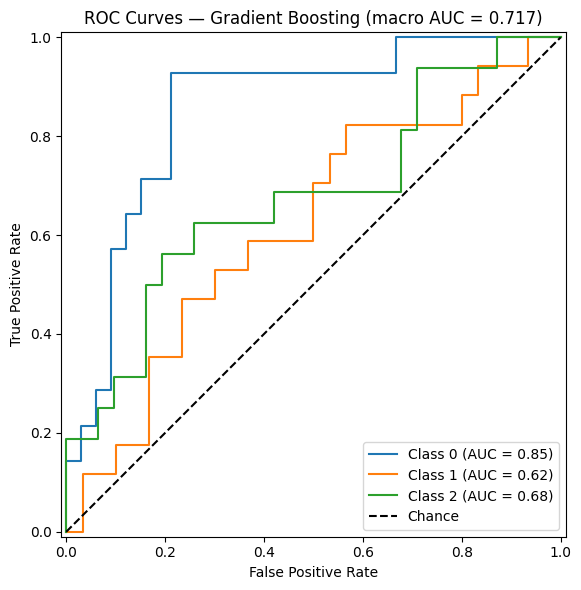

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, RocCurveDisplay

from sklearn.metrics import roc_auc_score
from sklearn.preprocessing import label_binarize

# Predict class probabilities for each test sample
y_prob = gb.predict_proba(X_test)     # Shape = (n_samples, n_classes)

# Get the class labels learned by the model (e.g., [0, 1] or [0, 1, 2])
classes = gb.classes_

# Number of unique classes
n_classes = len(classes)

# Case 1: Binary classification (2 classes)
if n_classes == 2:
    # AUC
    auc = roc_auc_score(y_test, y_prob[:, 1])
    print(f"ROC–AUC (binary): {auc:.3f}")

    # ROC curve
    fpr, tpr, _ = roc_curve(y_test, y_prob[:, 1])

    plt.figure(figsize=(6, 5))
    plt.plot(fpr, tpr, label=f"ROC curve (AUC = {auc:.3f})")
    plt.plot([0, 1], [0, 1], "k--", label="Chance")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("ROC Curve — Gradient Boosting")
    plt.legend(loc="lower right")
    plt.tight_layout()
    plt.show()

# Case 2: Multiclass classification (> 2 classes)
else:
    # Binarize y_test
    y_test_bin = label_binarize(y_test, classes=classes)

    # Macro-average AUC
    auc_macro = roc_auc_score(
        y_test_bin,
        y_prob,
        average="macro",
        multi_class="ovr"
    )
    print(f"ROC–AUC (multiclass, macro): {auc_macro:.3f}")

    # One-vs-rest ROC curves per class
    plt.figure(figsize=(7, 6))
    for i, c in enumerate(classes):
        RocCurveDisplay.from_predictions(
            y_test_bin[:, i],
            y_prob[:, i],
            name=f"Class {c}",
            ax=plt.gca()
        )

    plt.plot([0, 1], [0, 1], "k--", label="Chance")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"ROC Curves — Gradient Boosting (macro AUC = {auc_macro:.3f})")
    plt.legend(loc="lower right")
    plt.tight_layout()
    plt.show()

In [ ]:
import pandas as pd

# Predict class probabilities
y_prob = gb.predict_proba(X_test)      # shape = (n_samples, n_classes)

# Get class names from the model (e.g., [0, 1, 2])
classes = gb.classes_

# Convert to DataFrame
prob_table = pd.DataFrame(
    y_prob,
    columns=[f"Prob_Class_{c}" for c in classes]
)

# (Optional) add true label for comparison
prob_table["True_Label"] = y_test.values

# (Optional) add predicted class
prob_table["Predicted_Class"] = gb.predict(X_test)

# Show the first few rows
prob_table.head()

,Prob_Class_0,Prob_Class_1,Prob_Class_2,True_Label,Predicted_Class
0,0.723383,0.137496,0.139120,0,0
1,0.028750,0.176716,0.794534,2,2
2,0.901239,0.030558,0.068203,2,0
3,0.375107,0.599300,0.025593,0,1
4,0.028540,0.902248,0.069212,2,1


**Random Forest**

In [ ]:
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

In [ ]:
# Adjust the column name for our target variable:
#already done

In [ ]:
# Train Random Forest
'''
Creates a new Random Forest classifier object using scikit-learn.
A Random Forest is an ensemble of many decision trees that vote on the final prediction.
'''
rf = RandomForestClassifier(
    n_estimators=500,        # number of trees (More trees → more stable and accurate model, but slower.)
    max_depth=None,          # None means trees grow until all leaves are pure or contain fewer than 2 samples.
    class_weight="balanced", # handle class imbalance: Automatically adjusts weights inversely proportional to class frequencies.
    random_state=42,         # Sets a seed for reproducibility. Ensures we get the same results every time we run the code.
    n_jobs=-1                # Controls how many CPU cores to use. -1 = use all available cores for maximum speed during training.
)

rf.fit(X_train, y_train)     # Train the random forest model

RandomForestClassifier(class_weight='balanced', n_estimators=500, n_jobs=-1,
                       random_state=42)

In [ ]:
#Evaluate on test data
y_pred = rf.predict(X_test)  # Evaluate the model

print("Accuracy:", accuracy_score(y_test, y_pred)) #Finding accuracy
print("\nClassification Report:\n", classification_report(y_test, y_pred)) #determining classification report
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred)) #finding confusion matrix

Accuracy: 0.5106382978723404

Classification Report:
               precision    recall  f1-score   support

           0       0.56      0.64      0.60        14
           1       0.38      0.35      0.36        17
           2       0.60      0.56      0.58        16

    accuracy                           0.51        47
   macro avg       0.51      0.52      0.51        47
weighted avg       0.51      0.51      0.51        47

Confusion Matrix:
 [[9 5 0]
 [5 6 6]
 [2 5 9]]


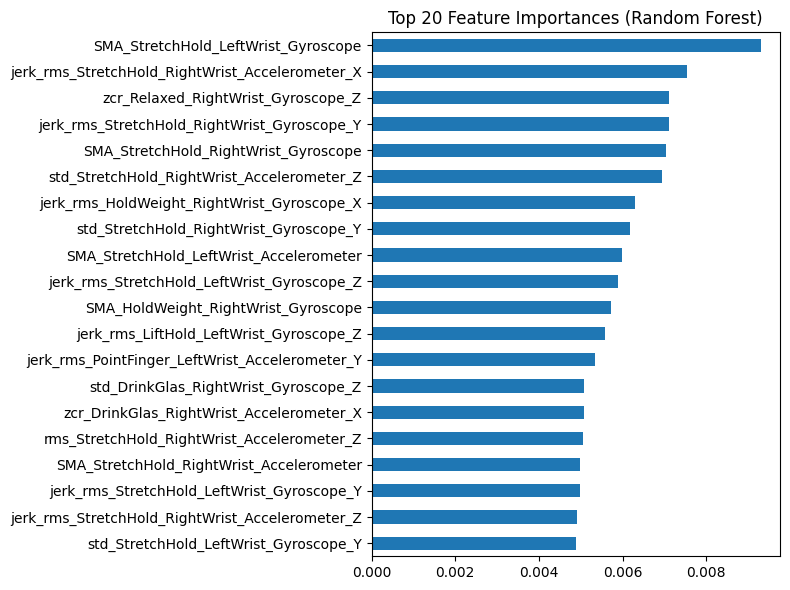

In [ ]:
#Feature importance
'''
After training, a Random Forest determines the importance of each feature in making decisions.
i. Each tree measures how much each feature reduces impurity (e.g., Gini impurity).
ii. These reductions are averaged across all trees.
iii. The final importance values are stored in:
To do that, we use rf.feature_importances_
'''

import matplotlib.pyplot as plt #plotting library used to create graphs.

'''
rf.feature_importances_
Gets an array of importance values calculated by the trained Random Forest (one value per feature).

pd.Series(...)
Converts that array into a pandas Series.

index=X_train.columns
Assigns each importance value to the correct feature name.
'''
importances = pd.Series(rf.feature_importances_, index=X_train.columns)

#A list of the 20 most important features with their importance scores
top = importances.sort_values(ascending=False).head(20)

plt.figure(figsize=(8, 6))
top.plot(kind='barh')
plt.title("Top 20 Feature Importances (Random Forest)")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

ROC–AUC (multiclass, macro): 0.712
ROC–AUC (multiclass, weighted): 0.701


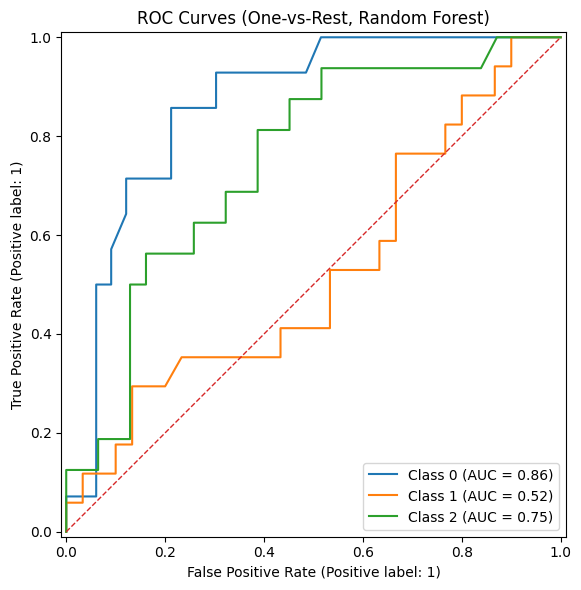

In [ ]:
# Probability outputs, ROC–AUC, and ROC plots

import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score, RocCurveDisplay
from sklearn.preprocessing import label_binarize

# 1) Predicted class probabilities
y_prob = rf.predict_proba(X_test)   # Predict probability for each class → shape = (n_samples, n_classes)
classes = rf.classes_               # Get the class labels learned by the model
n_classes = len(classes)            # Count how many classes (binary = 2, multiclass > 2)

# 2) ROC–AUC (works for binary or multiclass)
if n_classes == 2:
    # For binary classification: use probability of the positive class (column 1)
    auc = roc_auc_score(y_test, y_prob[:, 1])
    print(f"ROC–AUC (binary): {auc:.3f}")

    # Plot ROC curve using scikit-learn’s built-in visualization
    RocCurveDisplay.from_estimator(rf, X_test, y_test)
    plt.title("ROC Curve (Random Forest)")
    plt.tight_layout()
    plt.show()

else:
    # For multiclass: convert true labels into one-vs-rest binary indicators
    y_test_bin = label_binarize(y_test, classes=classes)

    # Compute One-vs-Rest macro AUC (average across all classes, treating each equally)
    auc_macro = roc_auc_score(y_test_bin, y_prob, average="macro", multi_class="ovr")

    # Weighted AUC (weights each class by its sample size)
    auc_weighted = roc_auc_score(y_test_bin, y_prob, average="weighted", multi_class="ovr")

    print(f"ROC–AUC (multiclass, macro): {auc_macro:.3f}")
    print(f"ROC–AUC (multiclass, weighted): {auc_weighted:.3f}")

    # Plot ROC curve for each class separately (One-vs-Rest)
    plt.figure(figsize=(7, 6))
    for i, cls in enumerate(classes):
        RocCurveDisplay.from_predictions(
            y_test_bin[:, i],    # True binary label for class i
            y_prob[:, i],        # Probability of class i
            name=f"Class {cls}", # Add class name to legend
            ax=plt.gca()         # Plot on the same axes
        )

    # Add diagonal line (random guess baseline)
    plt.plot([0, 1], [0, 1], linestyle="--", linewidth=1)
    plt.title("ROC Curves (One-vs-Rest, Random Forest)")
    plt.tight_layout()
    plt.show()

In [ ]:
# 3) Create a table of predicted probabilities
topk = 5                           # Number of rows to show
proba_df = (
    pd.DataFrame(y_prob, columns=[f"p(class={c})" for c in classes])  # Create a DataFrame with probability columns
    .assign(true=y_test.values,    # Add true label
            pred=rf.predict(X_test))  # Add predicted label
)

print("\nSample probability rows:")
display(proba_df.head(topk))       # Display first topk rows of the probability table


Sample probability rows:


,p(class=0),p(class=1),p(class=2),true,pred
0,0.354,0.440,0.206,0,1
1,0.182,0.390,0.428,2,2
2,0.374,0.332,0.294,2,0
3,0.412,0.354,0.234,0,0
4,0.178,0.404,0.418,2,2


**Support Vector Machine**

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, label_binarize
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    roc_auc_score, RocCurveDisplay
)

#1) Load data
#Already done in the previous model

# Split input features (X) and target labels (y)
#Already done in the previous model

In [ ]:
# 2) SVM pipeline (scaling + RBF SVM)

svm = Pipeline([
    ("scaler", StandardScaler(with_mean=False)),
    # StandardScaler scales each feature so SVM works better.
    # with_mean=False avoids errors if data is sparse.

    ("svc", SVC(kernel="rbf",                 # Use RBF kernel (default, good for nonlinear problems)
                C=10.0,                       # Regularization strength (higher = less regularization)
                gamma="scale",                # Automatic gamma setting based on feature variance
                class_weight="balanced",      # Handles imbalanced datasets by weighting classes
                probability=True,             # Enable probability prediction (for ROC–AUC)
                random_state=42))             # Ensures reproducibility
])

svm.fit(X_train, y_train)                     # Train the full pipeline (scaling + SVM)

Pipeline(steps=[('scaler', StandardScaler(with_mean=False)),
                ('svc',
                 SVC(C=10.0, class_weight='balanced', probability=True,
                     random_state=42))])

In [ ]:
# 3) Evaluate model

y_pred = svm.predict(X_test)                 # Predict class labels for test data

print("Accuracy:", round(accuracy_score(y_test, y_pred), 3))  # Compute accuracy

print("\nClassification Report:\n",
      classification_report(y_test, y_pred, digits=3))          # Precision, Recall, F1-score

print("Confusion Matrix:\n",
      confusion_matrix(y_test, y_pred))                         # TP, FP, FN, TN counts

Accuracy: 0.468

Classification Report:
               precision    recall  f1-score   support

           0      0.438     0.500     0.467        14
           1      0.500     0.471     0.485        17
           2      0.467     0.438     0.452        16

    accuracy                          0.468        47
   macro avg      0.468     0.469     0.468        47
weighted avg      0.470     0.468     0.468        47

Confusion Matrix:
 [[7 3 4]
 [5 8 4]
 [4 5 7]]


ROC–AUC (multiclass, macro): 0.723


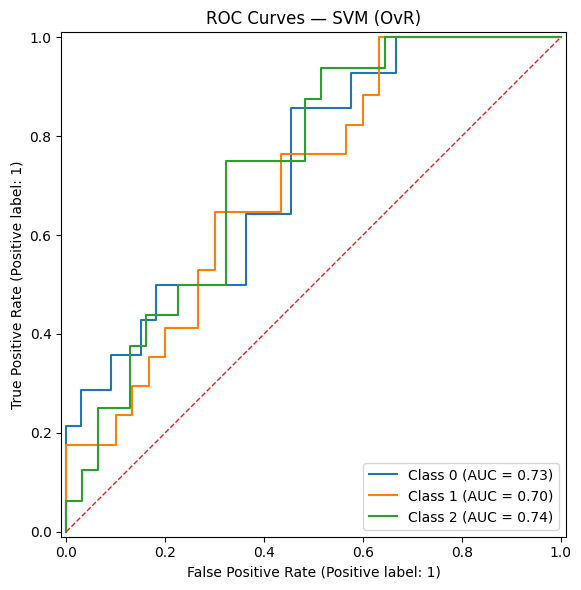

In [ ]:
# 4) ROC–AUC + ROC curves

y_prob = svm.predict_proba(X_test)           # Predict class probabilities for ROC curves
classes = svm.named_steps["svc"].classes_    # Extract ordered class labels
n_classes = len(classes)                     # Count number of classes

if n_classes == 2:
    # --- Binary classification case ---
    auc = roc_auc_score(y_test, y_prob[:, 1])   # Only probability of positive class (index 1)
    print(f"ROC–AUC (binary): {auc:.3f}")

    # Plot the ROC curve automatically
    RocCurveDisplay.from_estimator(svm, X_test, y_test)
    plt.title("ROC Curve — SVM (RBF)")
    plt.tight_layout()
    plt.show()

else:
    # --- Multiclass case (One-vs-Rest ROC) ---
    y_test_bin = label_binarize(y_test, classes=classes)   # Convert to binary indicator per class

    # Macro AUC = average AUC across classes
    auc_macro = roc_auc_score(y_test_bin, y_prob,
                              average="macro", multi_class="ovr")
    print(f"ROC–AUC (multiclass, macro): {auc_macro:.3f}")

    # Plot ROC curve for each class
    plt.figure(figsize=(7, 6))
    for i, c in enumerate(classes):
        RocCurveDisplay.from_predictions(
            y_test_bin[:, i],        # True binary label for class i
            y_prob[:, i],            # Predicted probability for class i
            name=f"Class {c}",       # Label in legend
            ax=plt.gca()             # Plot all curves on the same graph
        )

    plt.plot([0, 1], [0, 1], "--", lw=1)    # Diagonal = random guessing baseline
    plt.title("ROC Curves — SVM (OvR)")
    plt.tight_layout()
    plt.show()

In [ ]:
# 5) Probability table preview

proba_df = (
    pd.DataFrame(                         # Create DataFrame from class probabilities
        y_prob,
        columns=[f"p(class={c})" for c in classes]
    )
    .assign(true=y_test.values,           # Add true class label
            pred=y_pred)                  # Add predicted class label
)

print("\nSample probability rows:")
print(proba_df.head())                    # Show first few rows of probability table


Sample probability rows:
   p(class=0)  p(class=1)  p(class=2)  true  pred
0    0.407761    0.336660    0.255579     0     0
1    0.168925    0.308452    0.522622     2     2
2    0.325435    0.206843    0.467722     2     2
3    0.232905    0.342232    0.424863     0     2
4    0.056967    0.346726    0.596307     2     2


**XGBoost (eXtreme Gradient Boosting)**

In [ ]:
!pip install xgboost

In [ ]:
import pandas as pd
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# 1. Load train and test
# Already done

In [ ]:
# 2. Define XGBoost model

xgb = XGBClassifier(
    n_estimators=400,           # Number of boosting trees (more trees = more power)
    learning_rate=0.05,         # Shrinks updates → slower but more stable learning
    max_depth=6,                # Maximum depth of each tree (complexity)
    subsample=0.8,              # Use 80% of rows per tree (reduces overfitting)
    colsample_bytree=0.8,       # Use 80% of features per tree (reduces overfitting)
    objective="multi:softprob", # Multiclass probability output (works for 2 or 3+ classes)
    eval_metric="mlogloss",     # Evaluation metric for training (multiclass log-loss)
    random_state=42,            # Ensures reproducibility
    n_jobs=-1                   # Use all CPU cores for faster training
)
# 3. Train

xgb.fit(X_train, y_train)       # Fit the XGBoost model on the training data

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='mlogloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=6, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=400, n_jobs=-1,
              num_parallel_tree=None, ...)

In [ ]:
# 4. Predict

y_pred = xgb.predict(X_test)    # Predict class labels for the test dataset


# 5. Evaluate

print("Accuracy:", round(accuracy_score(y_test, y_pred), 3))
# Accuracy = proportion of correct predictions

print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
# Confusion matrix = true vs predicted class counts

print("\nClassification Report:\n", classification_report(y_test, y_pred, digits=3))
# Shows precision, recall, F1-score for each class (3 decimal places)

Accuracy: 0.489

Confusion Matrix:
 [[9 5 0]
 [5 7 5]
 [2 7 7]]

Classification Report:
               precision    recall  f1-score   support

           0      0.562     0.643     0.600        14
           1      0.368     0.412     0.389        17
           2      0.583     0.438     0.500        16

    accuracy                          0.489        47
   macro avg      0.505     0.497     0.496        47
weighted avg      0.499     0.489     0.490        47



ROC–AUC (multiclass, macro): 0.731


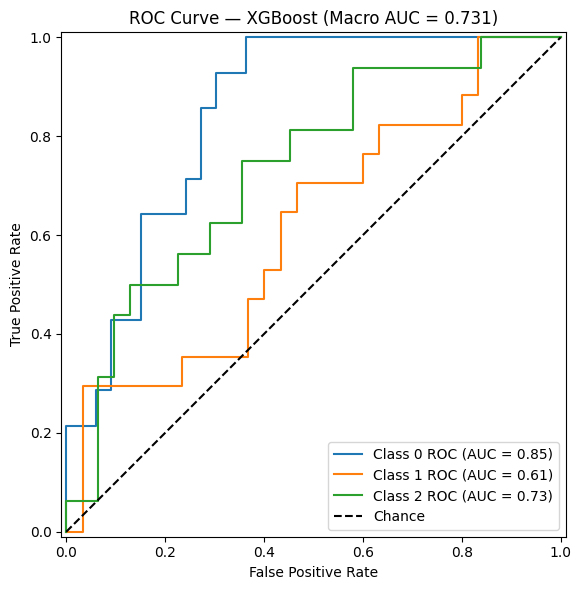

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score, RocCurveDisplay
from sklearn.preprocessing import label_binarize

# Predict class probabilities
y_prob = xgb.predict_proba(X_test)
classes = xgb.classes_
n_classes = len(classes)

# ============================
# Case 1 – Binary ROC Curve
# ============================
if n_classes == 2:

    # Compute AUC
    auc = roc_auc_score(y_test, y_prob[:, 1])
    print(f"ROC–AUC (binary): {auc:.3f}")

    # Compute ROC curve
    fpr, tpr, _ = roc_curve(y_test, y_prob[:, 1])

    # Plot
    plt.figure(figsize=(6, 5))
    plt.plot(fpr, tpr, label=f"XGBoost (AUC = {auc:.3f})")
    plt.plot([0, 1], [0, 1], "k--", label="Chance")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("ROC Curve — XGBoost")
    plt.legend(loc="lower right")
    plt.tight_layout()
    plt.show()

# ============================
# Case 2 – Multiclass ROC Curve (One-vs-Rest)
# ============================
else:
    # Binarize true labels
    y_test_bin = label_binarize(y_test, classes=classes)

    # Compute macro AUC
    auc_macro = roc_auc_score(
        y_test_bin,
        y_prob,
        average="macro",
        multi_class="ovr"
    )
    print(f"ROC–AUC (multiclass, macro): {auc_macro:.3f}")

    plt.figure(figsize=(7, 6))

    # Plot one ROC curve per class
    for i, c in enumerate(classes):
        RocCurveDisplay.from_predictions(
            y_test_bin[:, i],
            y_prob[:, i],
            name=f"Class {c} ROC",
            ax=plt.gca()
        )

    # Chance diagonal
    plt.plot([0, 1], [0, 1], "k--", label="Chance")

    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"ROC Curve — XGBoost (Macro AUC = {auc_macro:.3f})")
    plt.legend(loc="lower right")
    plt.tight_layout()
    plt.show()

In [ ]:
import pandas as pd

# Predict class probabilities for the test set
y_prob = xgb.predict_proba(X_test)          # shape = (n_samples, n_classes)

# Extract class labels learned by the model
classes = xgb.classes_

# Convert probabilities to a DataFrame
prob_table = pd.DataFrame(
    y_prob,
    columns=[f"Prob_Class_{c}" for c in classes]
)

# Add true label for comparison
prob_table["True_Label"] = y_test.values

# Add predicted class
prob_table["Predicted_Class"] = xgb.predict(X_test)

# Add row index (optional — helpful for merging)
prob_table["Sample_Index"] = prob_table.index

# Show table
prob_table.head()

,Prob_Class_0,Prob_Class_1,Prob_Class_2,True_Label,Predicted_Class,Sample_Index
0,0.378096,0.437658,0.184246,0,1,0
1,0.035190,0.140820,0.823990,2,2,1
2,0.641625,0.156828,0.201547,2,0,2
3,0.332412,0.633473,0.034115,0,1,3
4,0.068523,0.684214,0.247264,2,1,4
